# ov.genetics: a tour of statistical genetics in OmicVerse

`ov.genetics` is OmicVerse's unified post-GWAS analysis suite. It threads the major
human statistical-genetics analyses behind one registered, dispatch-based API:

1. **eQTL mapping** — `eqtl_map` (Matrix eQTL)
2. **Fine-mapping** — `finemap` / `get_credible_sets` / `get_pip` (SuSiE)
3. **Colocalization** — `colocalize` / `coloc_plot` (coloc)
4. **Mendelian randomization** — `mendelian_randomization` (TwoSampleMR)
5. **Single-cell disease relevance** — `disease_relevance_score` (scDRS)
6. **Heritability / LDSC** — `heritability` / `ldsc_cell_type` (LDSC)
7. **TWAS** — `twas` (S-PrediXcan / S-MultiXcan)

Each backend ships its own example data, so this notebook runs end-to-end with no
external downloads. The statistical machinery lives in seven standalone packages —
install them with `pip install omicverse[genetics]`.

Unlike single-cell modules, genetics data is heterogeneous: GWAS summary statistics
are DataFrames, genotypes are matrices, single-cell data is AnnData. `ov.genetics`
functions take whichever type the task naturally needs.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import omicverse as ov

print('omicverse', ov.__version__)
print('ov.genetics', ov.genetics.__version__)

omicverse 2.2.1rc1
ov.genetics 0.1.0


## 1. eQTL mapping

`ov.genetics.eqtl_map` scans every SNP-gene pair for a genotype-expression
association via Matrix eQTL. We use the bundled `pymatrixeqtl` example: 15 SNPs,
10 genes, 16 samples, plus 2 covariates. `model=` selects `'linear'` (additive
dosage), `'anova'` (genotype as a factor) or `'linear_cross'` (interaction).

In [2]:
import pymatrixeqtl

example = pymatrixeqtl.load_example()
snps, genes, cvrt = example['snps'], example['gene'], example['cvrt']
print('genotype :', snps.shape, '(SNPs x samples)')
print('expression:', genes.shape, '(genes x samples)')

genotype : (15, 16) (SNPs x samples)
expression: (10, 16) (genes x samples)


In [3]:
eqtl_res = ov.genetics.eqtl_map(
    snps, genes, cvrt,
    model='linear', pv_threshold=1.0,
)
print('SNP-gene tests:', eqtl_res.all.shape[0])
eqtl_res.all.sort_values('pvalue').head()

SNP-gene tests: 150


,snps,gene,beta,statistic,pvalue,FDR
0,Snp_05,Gene_03,0.410132,38.812160,5.515519e-14,8.273279e-12
1,Snp_13,Gene_09,-0.297885,-3.914403,2.055817e-03,1.541863e-01
2,Snp_11,Gene_06,-0.233247,-3.221962,7.327756e-03,2.853368e-01
3,Snp_04,Gene_10,0.232112,3.201666,7.608981e-03,2.853368e-01
4,Snp_14,Gene_01,0.214708,3.070005,9.716705e-03,2.915011e-01


## 2. Fine-mapping with SuSiE

`ov.genetics.finemap` resolves which variants in an associated locus are causal.
`method='susie'` uses individual-level genotype/phenotype; `method='susie_rss'`
uses GWAS summary statistics (z-scores + an LD matrix). We simulate a locus where
SNP 12 is the single causal variant.

In [4]:
rng = np.random.default_rng(0)
n_ind, n_snp = 800, 40
X = rng.normal(size=(n_ind, n_snp))
X = X - X.mean(axis=0)
beta_true = np.zeros(n_snp)
beta_true[12] = 0.6
y = X @ beta_true + rng.normal(size=n_ind)
print('locus:', X.shape, '- causal SNP index = 12')

locus: (800, 40) - causal SNP index = 12


In [5]:
# Summary statistics: marginal z-scores and the LD (correlation) matrix.
z = np.array([np.corrcoef(X[:, j], y)[0, 1] * np.sqrt(n_ind)
              for j in range(n_snp)])
R = np.corrcoef(X.T)

fit = ov.genetics.finemap(z=z, R=R, n=n_ind, method='susie_rss', L=5)
pip = ov.genetics.get_pip(fit)
print('top PIP SNP:', int(np.argmax(pip)), ' PIP =', round(float(pip.max()), 3))

top PIP SNP: 12  PIP = 1.0


95% credible sets: [array([12])]


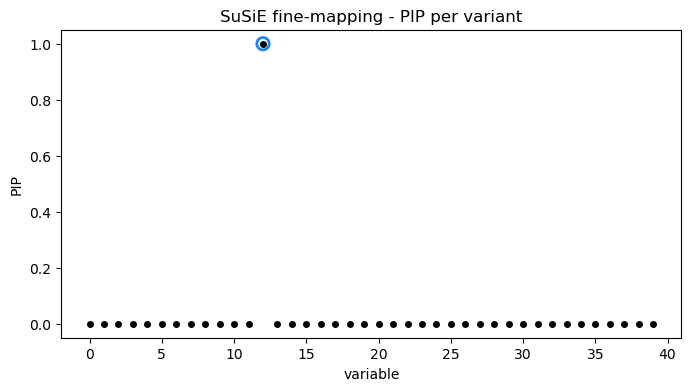

In [6]:
cs = ov.genetics.get_credible_sets(fit, R=R)
print('95% credible sets:', cs['cs'])
ax = ov.genetics.finemap_plot(fit)
ax.set_title('SuSiE fine-mapping - PIP per variant');

## 3. Colocalization

`ov.genetics.colocalize` tests whether two traits (e.g. a GWAS signal and an eQTL)
share a causal variant. `method='abf'` is the single-causal-variant Bayesian model;
it returns posterior probabilities `PP.H0..PP.H4` where **H4 = a shared causal
variant**. We build two datasets that share their causal SNP.

In [7]:
def make_coloc_dataset(seed, causal=50, n=120):
    r = np.random.default_rng(seed)
    beta = r.normal(0, 0.04, n)
    beta[causal] = 0.45  # shared causal variant
    return dict(snp=[f'rs{i}' for i in range(n)], position=np.arange(n),
                beta=beta, varbeta=np.full(n, 0.01), MAF=np.full(n, 0.3),
                type='quant', N=4000, sdY=1.0)

d_gwas = make_coloc_dataset(seed=1)
d_eqtl = make_coloc_dataset(seed=2)
print('two traits, shared causal SNP rs50')

two traits, shared causal SNP rs50


nsnps        120.000000
PP.H0.abf      0.203659
PP.H1.abf      0.013910
PP.H2.abf      0.013931
PP.H3.abf      0.000183
PP.H4.abf      0.768317
dtype: float64


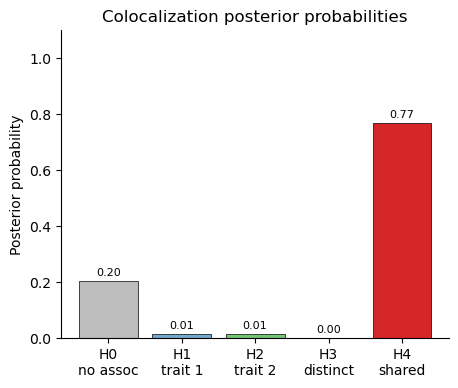

In [8]:
coloc_res = ov.genetics.colocalize(d_gwas, d_eqtl, method='abf')
print(coloc_res['summary'])
ov.genetics.coloc_plot(coloc_res);

## 4. Mendelian randomization

`ov.genetics.mendelian_randomization` estimates the causal effect of an exposure on
an outcome from GWAS summary statistics. `method=` picks the estimator — `'ivw'`,
`'egger'`, `'median'`, ... or `'all'` for a comparison table. We use the bundled
`pytwosamplemr` LDL-cholesterol &rarr; coronary-heart-disease example.

In [9]:
from pytwosamplemr.datasets import ldl_chd_input

mr_data = ldl_chd_input()
print('instruments (SNPs):', mr_data.nsnps)

ivw = ov.genetics.mendelian_randomization(mr_data, method='ivw')
print('IVW causal estimate:', round(ivw.estimate, 4),
      ' p =', f'{ivw.pvalue:.2e}')

instruments (SNPs): 28
IVW causal estimate: 2.8342  p = 8.82e-08


In [10]:
all_methods = ov.genetics.mendelian_randomization(mr_data, method='all')
all_methods

,Method,Estimate,Std Error,CILower,CIUpper,P-value
0,Simple median,1.755138,0.752693,0.279886,3.230390,1.971067e-02
1,Weighted median,2.682883,0.416425,1.866705,3.499061,1.173999e-10
2,Penalized weighted median,2.680929,0.418031,1.861603,3.500255,1.424696e-10
3,IVW,2.834214,0.529799,1.795826,3.872602,8.815013e-08
4,Penalized IVW,2.560914,0.412803,1.751834,3.369994,5.514624e-10
5,MR-Egger,3.252890,0.770129,1.743465,4.762316,2.401915e-05
6,(intercept),-0.011461,0.015188,-0.041229,0.018308,4.505065e-01
7,Penalized MR-Egger,3.420583,0.531038,2.379767,4.461399,1.184466e-10
8,(intercept),-0.021552,0.011046,-0.043203,0.000098,5.104809e-02


In [11]:
# Sensitivity analyses: heterogeneity + directional-pleiotropy tests.
het = ov.genetics.mr_heterogeneity(mr_data)
ple = ov.genetics.mr_pleiotropy(mr_data)
print('Cochran Q heterogeneity:'); print(het)
print('\nMR-Egger intercept (pleiotropy):'); print(ple)

Cochran Q heterogeneity:
                      method          Q  Q_df        Q_pval
0  Inverse variance weighted  99.530426    27  3.073695e-10
1                   MR Egger  97.397505    26  3.463692e-10

MR-Egger intercept (pleiotropy):
   egger_intercept        se      pval
0        -0.011461  0.015188  0.450506


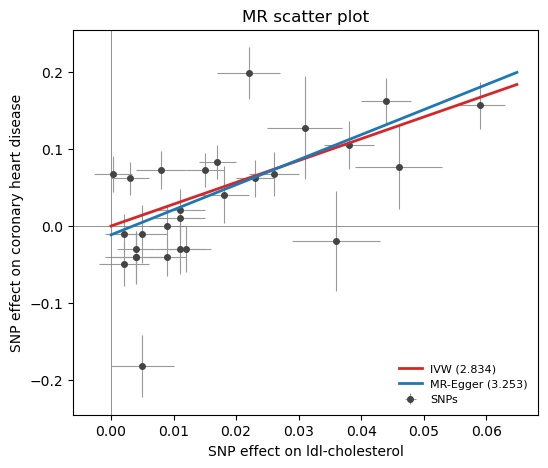

In [12]:
ov.genetics.mr_scatter(mr_data);

## 5. Single-cell disease-relevance scoring (scDRS)

`ov.genetics.disease_relevance_score` links a GWAS to single-cell expression: each
cell gets a normalised disease-relevance score and an empirical p-value. This is the
one `ov.genetics` task that is genuinely AnnData-native. We build a small synthetic
scRNA-seq dataset where the first 40 genes carry a disease signal in cell-type A.

In [13]:
import anndata
import scipy.sparse as sp

rng = np.random.default_rng(0)
counts = rng.poisson(1.0, size=(400, 500)).astype(np.float32)
counts[:200, :40] += rng.poisson(3.0, size=(200, 40))  # disease signal in A
lib = counts.sum(1, keepdims=True); lib[lib == 0] = 1
X = np.log1p(counts / lib * 1e4).astype(np.float32)
print('synthetic scRNA-seq counts:', X.shape, '(cells x genes)')

synthetic scRNA-seq counts: (400, 500) (cells x genes)


In [14]:
obs = pd.DataFrame({'cell_type': ['A'] * 200 + ['B'] * 200},
                   index=[f'cell{i}' for i in range(400)])
var = pd.DataFrame(index=[f'gene{i}' for i in range(500)])
adata = anndata.AnnData(X=sp.csr_matrix(X), obs=obs, var=var)
disease_genes = [f'gene{i}' for i in range(40)]
print(adata)

AnnData object with n_obs × n_vars = 400 × 500
    obs: 'cell_type'


In [15]:
score = ov.genetics.disease_relevance_score(
    adata, gene_set=disease_genes, n_ctrl=100,
)
score.head()

Too few genes for 20*20 bins, setting n_mean_bin=n_var_bin=7


,raw_score,norm_score,mc_pval,pval,nlog10_pval,zscore
cell0,4.014663,3.074417,0.009901,0.000925,3.033869,3.113320
cell1,4.067713,2.825552,0.019802,0.002025,2.693586,2.874249
cell2,3.931377,0.283141,0.396040,0.388440,0.410676,0.283386
cell3,3.576118,0.124316,0.415842,0.449839,0.346943,0.126069
cell4,3.948185,2.317974,0.019802,0.009750,2.011006,2.335841


In [16]:
# Cell-group downstream analysis needs a neighbour graph.
import scanpy as sc
sc.pp.pca(adata, n_comps=20)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)

group = ov.genetics.score_downstream(
    adata, score, analysis='group', group_cols=['cell_type'],
)
group['cell_type']

,n_cell,n_ctrl,assoc_mcp,assoc_mcz,hetero_mcp,hetero_mcz,n_fdr_0.05,n_fdr_0.1,n_fdr_0.2
group,,,,,,,,,
A,200.0,0.0,1.0,NaN,1.0,NaN,158.0,176.0,187.0
B,200.0,0.0,1.0,NaN,1.0,NaN,0.0,0.0,0.0


Cell-type **A** (which carries the planted disease signal) shows the higher mean
score and a larger fraction of significant cells, as expected.

## 6. Heritability and LDSC-SEG

`ov.genetics.heritability` estimates SNP-heritability by LD score regression;
`ov.genetics.ldsc_cell_type` runs the LDSC-SEG cell-type / tissue enrichment
analysis. These use file-path inputs (`.sumstats` + LD-score filesets). We use the
`ldsc` reference test data shipped with the `pyldsc` test suite.

In [17]:
import os

LDSC_SIM = '/tmp/ldsc_ref/test/simulate_test'
HAVE_LDSC = os.path.isdir(LDSC_SIM)
print('ldsc reference data available:', HAVE_LDSC)

ldsc reference data available: True


In [18]:
if HAVE_LDSC:
    h2 = ov.genetics.heritability(
        f'{LDSC_SIM}/sumstats/1',
        ref_ld=f'{LDSC_SIM}/ldscore/oneld_onefile',
        w_ld=f'{LDSC_SIM}/ldscore/w',
    )
    print(f'SNP-heritability h2 = {h2.tot:.4f} (SE {h2.tot_se:.4f})')
    print(f'LDSC intercept      = {h2.intercept:.4f}')
else:
    print('skipping heritability (reference data not present)')

SNP-heritability h2 = 0.7366 (SE 0.0665)
LDSC intercept      = 2.9081


In [19]:
if HAVE_LDSC:
    cts = ov.genetics.ldsc_cell_type(
        f'{LDSC_SIM}/sumstats/1',
        ref_ld_cts=[('cell_type_A', f'{LDSC_SIM}/ldscore/twold_onefile')],
        ref_ld=f'{LDSC_SIM}/ldscore/oneld_onefile',
        w_ld=f'{LDSC_SIM}/ldscore/w',
    )
    print('LDSC-SEG cell-type enrichment:')
    print(cts)
else:
    print('skipping LDSC-SEG (reference data not present)')

LDSC-SEG cell-type enrichment:
          Name  Coefficient  Coefficient_std_error  Coefficient_P_value
0  cell_type_A    -0.048212               0.053836             0.814749


## 7. TWAS (S-PrediXcan)

`ov.genetics.twas` tests genetically-predicted gene expression for association with
a trait, nominating candidate effector genes from a GWAS. `method='spredixcan'`
runs the single-tissue summary-statistics TWAS from a GWAS + a prediction model +
a SNP-covariance file. We use the bundled `pytwas` demo data.

In [20]:
import pytwas

twas_dir = os.path.join(os.path.dirname(pytwas.__file__), '..', 'examples', 'data')
twas_dir = os.path.abspath(twas_dir)
gwas_df = ov.genetics.read_sumstats(os.path.join(twas_dir, 'demo_gwas.txt.gz'))
print('GWAS summary stats:', gwas_df.shape)
gwas_df.head()

GWAS summary stats: (398, 5)


,SNP,A1,A2,Z,P
0,rs0,A,G,-0.221862,0.824422
1,rs1,G,A,0.418139,0.675846
2,rs2,G,A,-0.431255,0.666283
3,rs3,C,T,0.272261,0.785422
4,rs4,T,C,-0.114798,0.908605


In [21]:
twas_res = ov.genetics.twas(
    gwas=gwas_df,
    model=os.path.join(twas_dir, 'demo_model.db'),
    covariance=os.path.join(twas_dir, 'demo_cov.txt.gz'),
    method='spredixcan',
    zscore_column='Z',
)
print('genes tested:', twas_res.shape[0])
twas_res.sort_values('pvalue').head()

genes tested: 80


,gene,gene_name,zscore,effect_size,pvalue,var_g,pred_perf_r2,pred_perf_pval,pred_perf_qval,n_snps_used,n_snps_in_cov,n_snps_in_model
0,ENSG00000000023.1,GENE23,19.891121,NaN,4.857717e-88,0.414203,0.043953,0.000364,0.005032,7,7,7
1,ENSG00000000066.1,GENE66,18.786700,NaN,9.702920e-79,0.302738,0.087731,0.032342,0.048915,7,7,7
2,ENSG00000000041.1,GENE41,11.668276,NaN,1.851378e-31,0.039202,0.251323,0.026276,0.014847,5,5,5
3,ENSG00000000058.1,GENE58,8.010402,NaN,1.143345e-15,0.154549,0.462714,0.039951,0.034540,3,3,3
4,ENSG00000000007.1,GENE7,6.757112,NaN,1.407692e-11,0.152741,0.449635,0.049164,0.011502,5,5,5


## 8. GWAS core: association scan and diagnostics

`ov.genetics` also ships a backend-free GWAS core implemented on numpy / scipy /
statsmodels: `gwas_association` (per-SNP linear or logistic regression),
`genomic_inflation` (lambda GC) and `gwas_qc`. Here we simulate a cohort where SNP
20 truly affects a quantitative trait.

In [22]:
rng = np.random.default_rng(42)
n_samp, n_var = 500, 200
G = rng.integers(0, 3, size=(n_samp, n_var)).astype(float)
pheno = 0.7 * G[:, 20] + rng.normal(size=n_samp)

assoc = ov.genetics.gwas_association(G, pheno, model='linear')
lam = ov.genetics.genomic_inflation(assoc['pvalue'])
print('top SNP:', assoc.iloc[0]['snp'], ' p =', f"{assoc.iloc[0]['pvalue']:.2e}")
print('genomic inflation lambda_GC =', round(lam, 3))

top SNP: snp20  p = 2.50e-31
genomic inflation lambda_GC = 0.965


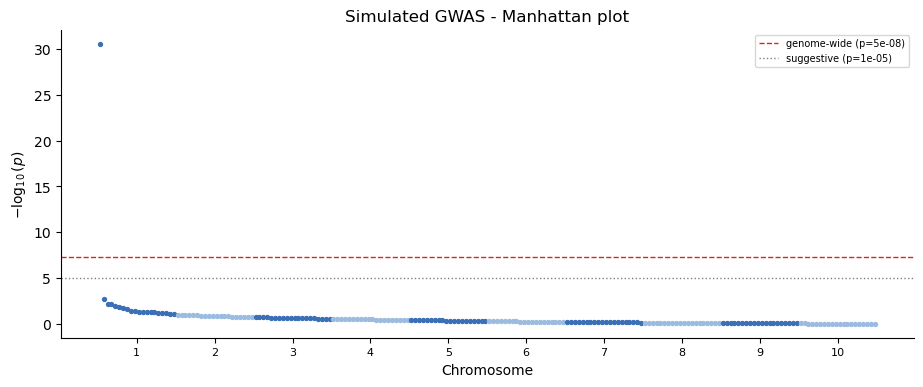

In [23]:
# Add chromosome / position columns for a Manhattan plot.
assoc['CHR'] = np.repeat(np.arange(1, 11), 20)
assoc['BP'] = np.tile(np.arange(20) * 1e5, 10)
ov.genetics.manhattan(assoc, chrom='CHR', pos='BP', pvalue='pvalue',
                      title='Simulated GWAS - Manhattan plot');

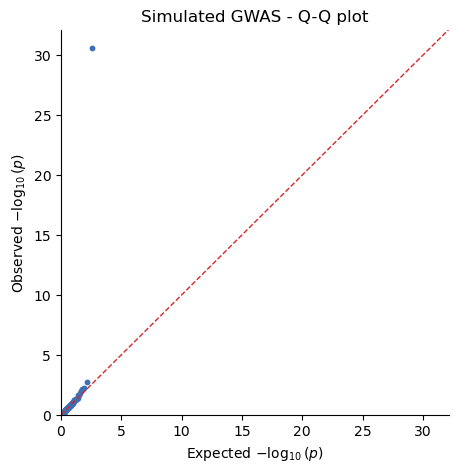

In [24]:
ov.genetics.qqplot(assoc, pvalue='pvalue',
                   title='Simulated GWAS - Q-Q plot');

## Summary

In one notebook we ran the full post-GWAS pipeline through `ov.genetics`:

| Stage | Function | Backend |
|---|---|---|
| eQTL mapping | `eqtl_map` | pymatrixeqtl |
| Fine-mapping | `finemap`, `get_pip`, `get_credible_sets` | pysusie |
| Colocalization | `colocalize`, `coloc_plot` | pycoloc |
| Mendelian randomization | `mendelian_randomization`, `mr_heterogeneity`, `mr_pleiotropy` | pytwosamplemr |
| Single-cell disease relevance | `disease_relevance_score`, `score_downstream` | pyscdrs |
| Heritability / LDSC-SEG | `heritability`, `ldsc_cell_type` | pyldsc |
| TWAS | `twas` | pytwas |
| GWAS core + plots | `gwas_association`, `genomic_inflation`, `manhattan`, `qqplot` | (no backend) |

Every function is `@register_function`-decorated under `category='genetics'`, so it
is discoverable via `ov.find_function(...)`. Install all backends with
`pip install omicverse[genetics]`.